In [1]:
include("../RayTracing.jl")
using Plots

In [2]:
mutable struct StratifiedSampler <: RayTracing.AbstractSampler
    samples_per_pixel::Int64
    x_samples::Int64
    y_samples::Int64
    jitter::Bool
    pixel::RayTracing.Pnt2
    sample_index::Int64
    dimension::Int64
    seed::Int64

    function StratifiedSampler(samples_per_pixel::Int64, jitter::Bool, seed::Int64=123456789)
        d = Int(trunc(sqrt(samples_per_pixel)))
        while samples_per_pixel % d != 0
            d -= 1
        end
        x_samples = samples_per_pixel / d
        y_samples = samples_per_pixel / x_samples
        return new(samples_per_pixel, x_samples, y_samples, jitter, RayTracing.Pnt2(-1,-1), 0, 0, seed)
    end
end

function start_pixel!(ss::StratifiedSampler, pixel::RayTracing.Pnt2, sample_index::Int64)
    ss.pixel = pixel
    ss.sample_index = sample_index
    ss.dimension = 0
end

function get_1D!(ss::StratifiedSampler)::Float64
    ha = hash((ss.pixel, ss.dimension, ss.seed))
    stratum = permutation_element(UInt32(ss.sample_index), UInt32(ss.samples_per_pixel), ha)

    ss.dimension += 1
    delta = ss.jitter ? rand(Float32) : Float32(0.5)
    return (stratum + delta) / ss.samples_per_pixel
end

function get_2D!(ss::StratifiedSampler)::RayTracing.Pnt2
    ha = hash((ss.pixel, ss.dimension, ss.seed))
    stratum = permutation_element(UInt32(ss.sample_index), UInt32(ss.samples_per_pixel), ha)

    ss.dimension += 2
    x = stratum % ss.x_samples
    y = stratum ÷ ss.x_samples
    dx = ss.jitter ? rand(Float32) : Float32(0.5)
    dy = ss.jitter ? rand(Float32) : Float32(0.5)
    return RayTracing.Pnt2((x+dx)/ss.x_samples, (y+dy)/ss.y_samples)
end

function __inner_loop(i::UInt32, p::UInt32, w::UInt32)::UInt32
    i ⊻= p
    i *= 0xe170893d
    i ⊻= p >> 16
    i ⊻= (i & w) >> 4
    i ⊻= p >> 8
    i *= 0x0929eb3f
    i ⊻= p >> 23
    i ⊻= (i & w) >> 1
    i *= UInt32(1) | (p >> 27) # careful on casting here. need not worry on bit shifts
    i *= 0x6935fa69
    i ⊻= (i & w) >> 11
    i *= 0x74dcb303
    i ⊻= (i & w) >> 2
    i *= 0x9e501cc3
    i ⊻= (i & w) >> 2
    i *= 0xc860a3df
    i &= w
    i ⊻= i >> 5
    return i
end

function permutation_element(i::UInt32, l::UInt32, p::Union{UInt, Int})::Int64
    p = UInt32(p & typemax(UInt32)) # PBRT's hash is a uint64_t and PermutationElement does the truncation. we have to do it explicitly.
    w = l - UInt32(1) # careful on casting
    w |= w >> 1
    w |= w >> 2
    w |= w >> 4
    w |= w >> 8
    w |= w >> 16
    i = __inner_loop(i, p, w) # We don't have a do-while only while-do
    while i >= l
        i = __inner_loop(i, p, w)
    end
    return (i + p) % l
end

permutation_element (generic function with 1 method)

In [3]:
@assert stratum = permutation_element(UInt32(0), UInt32(36), 400) == 26
@assert stratum = permutation_element(UInt32(0), UInt32(36), 4032212079371261838) == 15

In [4]:
tiles = [
    [RayTracing.Pnt2(1,1), RayTracing.Pnt2(2,1), RayTracing.Pnt2(3,1)],
    [RayTracing.Pnt2(1,2), RayTracing.Pnt2(2,2), RayTracing.Pnt2(3,2)],
    [RayTracing.Pnt2(1,3), RayTracing.Pnt2(2,3), RayTracing.Pnt2(3,3)],
]
tiles = [
    [RayTracing.Pnt2(1,1)],
]

1-element Vector{Vector{Main.RayTracing.Pnt2}}:
 [[1.0, 1.0]]

In [5]:
px1 = []
py1 = []
px2 = []
py2 = []
px3 = []
py3 = []
for tile in tiles
    ss = StratifiedSampler(1024, true)
    for pixel in tile
        for s in 1:ss.samples_per_pixel
            start_pixel!(ss, pixel, s)
            p = get_2D!(ss)
            append!(px1, p.x)
            append!(py1, p.y)
            p = get_2D!(ss)
            append!(px2, p.x)
            append!(py2, p.y)
            p = get_2D!(ss)
            append!(px3, p.x)
            append!(py3, p.y)
        end
    end
end

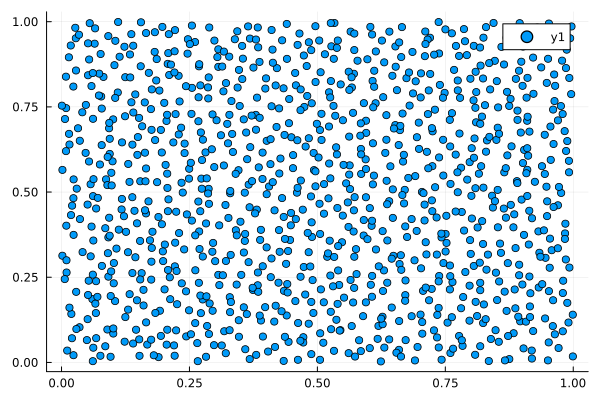

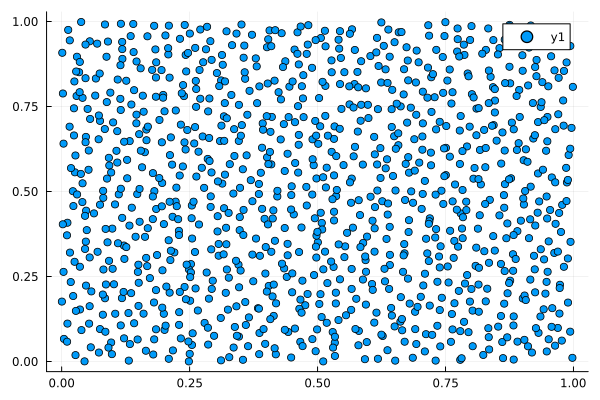

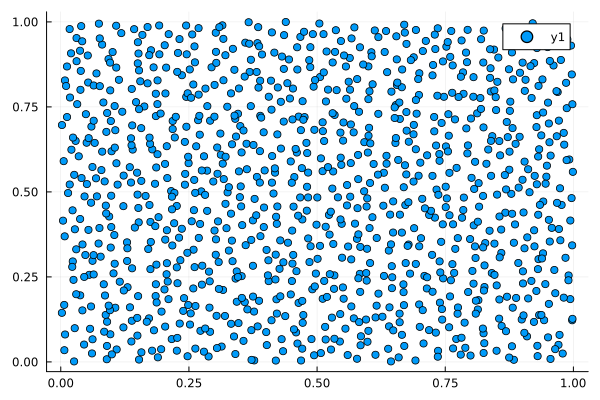

In [6]:
for (a,b) in [(px1, py1), (px2, py2), (px3, py3)]
    Plots.display(plot(a, b, seriestype=:scatter))
end

# speed test

In [7]:
100 * 100 * 100

1000000

In [17]:
function go()
    c = 0
    for x in 1:10
        for y in 1:10
            for z in 1:10
                c += 1
                ha = hash((x,y,z))
                p = permutation_element(UInt32(x), UInt32(y), ha)
            end
        end
    end
    return c
end


go (generic function with 1 method)

In [18]:
@time go()

In [10]:
# /******************************************************************************

#                               Online C++ Compiler.
#                Code, Compile, Run and Debug C++ program online.
# Write your code in this editor and press "Run" button to compile and execute it.

# *******************************************************************************/

# #include <iostream>
# using namespace std;

# inline int PermutationElement(uint32_t i, uint32_t l, uint32_t p) {
#     uint32_t w = l - 1;
#     w |= w >> 1;
#     w |= w >> 2;
#     w |= w >> 4;
#     w |= w >> 8;
#     w |= w >> 16;
#     do {
#         i ^= p;
#         i *= 0xe170893d;
#         i ^= p >> 16;
#         i ^= (i & w) >> 4;
#         i ^= p >> 8;
#         i *= 0x0929eb3f;
#         i ^= p >> 23;
#         i ^= (i & w) >> 1;
#         i *= 1 | p >> 27;
#         i *= 0x6935fa69;
#         i ^= (i & w) >> 11;
#         i *= 0x74dcb303;
#         i ^= (i & w) >> 2;
#         i *= 0x9e501cc3;
#         i ^= (i & w) >> 2;
#         i *= 0xc860a3df;
#         i &= w;
#         i ^= i >> 5;
#     } while (i >= l);
#     return (i + p) % l;
# }

# int main()
# {
#     uint32_t l = 36;
#     uint64_t p = 4032212079371261838;
#     for (int i = 0; i < 36; i++){
#         cout << PermutationElement(i, l, p) << "\n";
#         int stratum = PermutationElement(i, l, p);
#         int x = stratum % 6;
#         int y = stratum / 6;
#         cout << "(" << x << "," << y << ")\n";
#         float dx = 0.5f;
#         float dy = 0.5f;
#         cout << (x+dx)/6 << ":" << (y+dy)/6 << "\n\n";
#     }
    

#     return 0;
# }
